# 07 — Cartesian Recovery: Can the Concentric System Reproduce Known Physics?

## The Challenge

NB01-06 established that nested concentric oscillators with prime frequencies produce
specific mathematical properties: an exponential return-rate gradient, zero resonance,
bounded approximation quality, and complete state space.

We proposed that this constitutes a **coordinate system** — a way to measure and describe
reality. If so, it must pass the most basic validation test:

**Can it reproduce what the Cartesian coordinate system already succeeds at?**

You don't validate a new ruler by measuring something nobody has measured before.
You validate it by measuring something you already know the answer to.

### What the Cartesian System Succeeds At

| Test | Cartesian prediction | Required result |
|------|---------------------|------------------|
| **Distance** | $ds^2 = dx^2 + dy^2 + dz^2$ | Recoverable from concentric metric |
| **Free motion** | Straight lines at constant velocity | Geodesics in concentric coords must be straight lines in flat limit |
| **Gravitational orbits** | Kepler's laws, inverse-square law | Nesting gradient must map to gravitational potential |
| **Curvature** | Schwarzschild metric, GR predictions | Concentric geometry must include curvature as a natural feature |

If the concentric system cannot match these, it is not a coordinate system — it is a metaphor.

### The Concentric Coordinate System

A point in the concentric system is specified by angular positions on nested prime orbits:

$$\mathbf{q} = (\theta_2, \theta_3, \theta_5, \theta_7, \ldots)$$

Each orbit has:
- Angular frequency $\omega_p = 2\pi\sqrt{p}$
- Some characteristic radius $r_p$ (to be determined)
- Free evolution: $\theta_p(t) = \omega_p \cdot t \mod 2\pi$

The metric tensor in these coordinates determines all geometry:

$$ds^2 = \sum_{i,j} g_{ij} \, d\theta_i \, d\theta_j$$

For the simplest case (diagonal metric, no cross-terms):

$$ds^2 = \sum_p r_p^2 \, d\theta_p^2$$

**The critical question**: what determines $r_p$, and does the resulting geometry
match physical reality?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

# The four primes and their frequencies
primes = np.array([2, 3, 5, 7])
omega = 2 * np.pi * np.sqrt(primes.astype(float))

print('Concentric Coordinate System — Basic Parameters')
print('=' * 60)
for i, p in enumerate(primes):
    print(f'  Orbit p={p}: ω = 2π√{p} = {omega[i]:.4f} rad/s')
    print(f'    Period T = {2*np.pi/omega[i]:.4f} s')
    print(f'    If v=1: r = 1/ω = {1/omega[i]:.6f}')

Concentric Coordinate System — Basic Parameters
  Orbit p=2: ω = 2π√2 = 8.8858 rad/s
    Period T = 0.7071 s
    If v=1: r = 1/ω = 0.112540
  Orbit p=3: ω = 2π√3 = 10.8828 rad/s
    Period T = 0.5774 s
    If v=1: r = 1/ω = 0.091888
  Orbit p=5: ω = 2π√5 = 14.0496 rad/s
    Period T = 0.4472 s
    If v=1: r = 1/ω = 0.071176
  Orbit p=7: ω = 2π√7 = 16.6237 rad/s
    Period T = 0.3780 s
    If v=1: r = 1/ω = 0.060155


## Part 1: The Metric Tensor

### Choosing the Radii

The frequency structure $\omega_p = 2\pi\sqrt{p}$ suggests a natural radius assignment.
For a circular orbit with angular velocity $\omega$ and unit linear velocity:

$$r_p = \frac{1}{\omega_p} = \frac{1}{2\pi\sqrt{p}}$$

This means higher primes = smaller radii = finer structure. The first orbit (p=2)
has the largest radius; each successive orbit adds smaller, finer detail.

But we should also test other radius assignments to see which one (if any)
recovers Euclidean geometry:

| Assignment | $r_p$ | Physical interpretation |
|-----------|--------|-------------------------|
| Frequency-inverse | $1/(2\pi\sqrt{p})$ | Unit velocity orbits |
| Square-root | $\sqrt{p}$ | Radius grows with prime |
| Linear | $p$ | Radius = prime itself |
| Constant | $1$ | Flat torus, all radii equal |

In [2]:
# Define multiple radius assignments and compute their metric properties

radius_assignments = {
    'freq_inverse': 1.0 / omega,                    # r = 1/ω
    'sqrt_p': np.sqrt(primes.astype(float)),         # r = √p  
    'linear_p': primes.astype(float),                # r = p
    'constant': np.ones(4),                          # r = 1
}

print('Metric Tensor Components g_pp = r_p² for Different Radius Assignments')
print('=' * 70)
print(f'{"Assignment":>15} | {"g_22":>10} {"g_33":>10} {"g_55":>10} {"g_77":>10} | {"det(g)":>12}')
print('-' * 70)

for name, r in radius_assignments.items():
    g = r**2  # diagonal metric components
    det_g = np.prod(g)  # determinant = product for diagonal matrix
    print(f'{name:>15} | {g[0]:10.6f} {g[1]:10.6f} {g[2]:10.6f} {g[3]:10.6f} | {det_g:12.6e}')

print()
print('Key observation: the metric is DIAGONAL in all cases.')
print('This means the concentric coordinates are orthogonal —')
print('each prime orbit is genuinely independent of every other.')
print('This is the metric expression of the primorial property from NB06.')

Metric Tensor Components g_pp = r_p² for Different Radius Assignments
     Assignment |       g_22       g_33       g_55       g_77 |       det(g)
----------------------------------------------------------------------
   freq_inverse |   0.012665   0.008443   0.005066   0.003619 | 1.960387e-09
         sqrt_p |   2.000000   3.000000   5.000000   7.000000 | 2.100000e+02
       linear_p |   4.000000   9.000000  25.000000  49.000000 | 4.410000e+04
       constant |   1.000000   1.000000   1.000000   1.000000 | 1.000000e+00

Key observation: the metric is DIAGONAL in all cases.
This means the concentric coordinates are orthogonal —
each prime orbit is genuinely independent of every other.
This is the metric expression of the primorial property from NB06.


## Part 2: Embedding in Physical Space

The concentric system lives on a torus (product of circles). Physical space is $\mathbb{R}^3$.
To compare, we need an **embedding** — a map from concentric coordinates to Cartesian.

### The Epicyclic Embedding

The simplest embedding: treat each orbit as an epicycle (circle carried by the previous circle).
This is the classical Ptolemaic construction:

$$x(t) = \sum_p r_p \cos(\theta_p(t))$$
$$y(t) = \sum_p r_p \sin(\theta_p(t))$$

This maps the 4-torus into a 2D plane. The trajectory traces an epicycloid.

**Critical question**: what does this trajectory look like? Is it:
- A straight line? (free particle)
- A closed orbit? (bound system)
- Something else entirely?

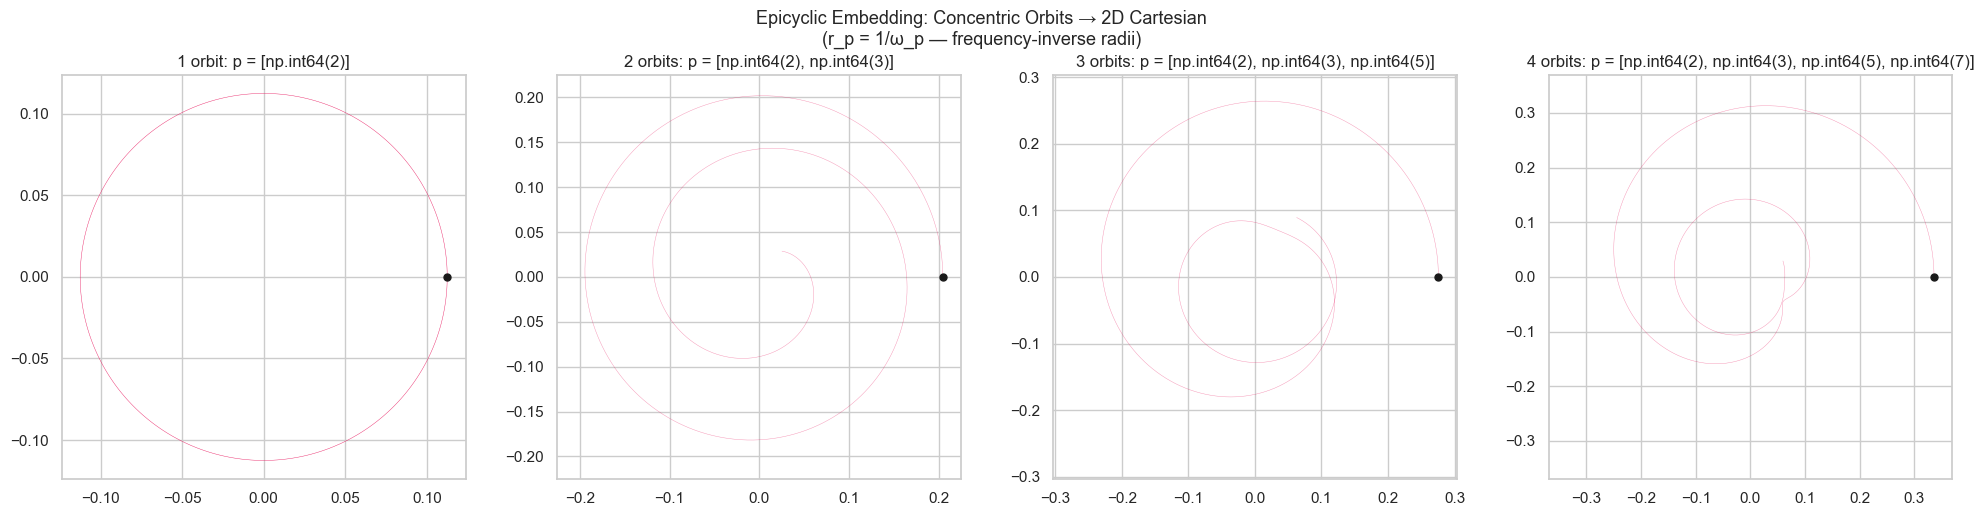

Radii: [0.11253954 0.09188815 0.07117625 0.06015491]
Total extent (sum of radii): 0.335759
Ratio r_max/r_min: 1.871


In [3]:
# Epicyclic embedding: map concentric coordinates to 2D plane

# Use freq_inverse radii (natural choice from ω structure)
r = 1.0 / omega  # r_p = 1/(2π√p)

# Time array — several full cycles of the slowest oscillator
T_slowest = 2 * np.pi / omega[0]  # period of orbit p=2
t = np.linspace(0, 20 * T_slowest, 100_000)

# Angular positions
theta = np.array([np.mod(omega[i] * t, 2 * np.pi) for i in range(4)])

# Epicyclic embedding: x = Σ r_p cos(θ_p), y = Σ r_p sin(θ_p)
def epicyclic_embed(theta_all, radii):
    """Map angular positions on nested orbits to 2D Cartesian."""
    x = np.sum(radii[:, np.newaxis] * np.cos(theta_all), axis=0)
    y = np.sum(radii[:, np.newaxis] * np.sin(theta_all), axis=0)
    return x, y

# Embed with different numbers of orbits (1, 2, 3, 4)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for n_orbits in range(1, 5):
    ax = axes[n_orbits - 1]
    x, y = epicyclic_embed(theta[:n_orbits], r[:n_orbits])
    
    # Plot trajectory (subsample for clarity)
    n_plot = min(10000, len(x))
    ax.plot(x[:n_plot], y[:n_plot], '-', linewidth=0.3, alpha=0.5, color='#E91E63')
    ax.plot(x[0], y[0], 'ko', markersize=5)  # start
    ax.set_aspect('equal')
    ax.set_title(f'{n_orbits} orbit{"s" if n_orbits > 1 else ""}: p = {list(primes[:n_orbits])}')
    
    # Show the maximum extent
    max_r = np.sum(r[:n_orbits])
    ax.set_xlim(-max_r*1.1, max_r*1.1)
    ax.set_ylim(-max_r*1.1, max_r*1.1)

fig.suptitle('Epicyclic Embedding: Concentric Orbits → 2D Cartesian\n'
             '(r_p = 1/ω_p — frequency-inverse radii)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Radii: {r}')
print(f'Total extent (sum of radii): {np.sum(r):.6f}')
print(f'Ratio r_max/r_min: {r[0]/r[-1]:.3f}')

C:\Users\mlf\AppData\Local\Temp\ipykernel_19076\2532490168.py:18: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\mlf\.conda\envs\concentric\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


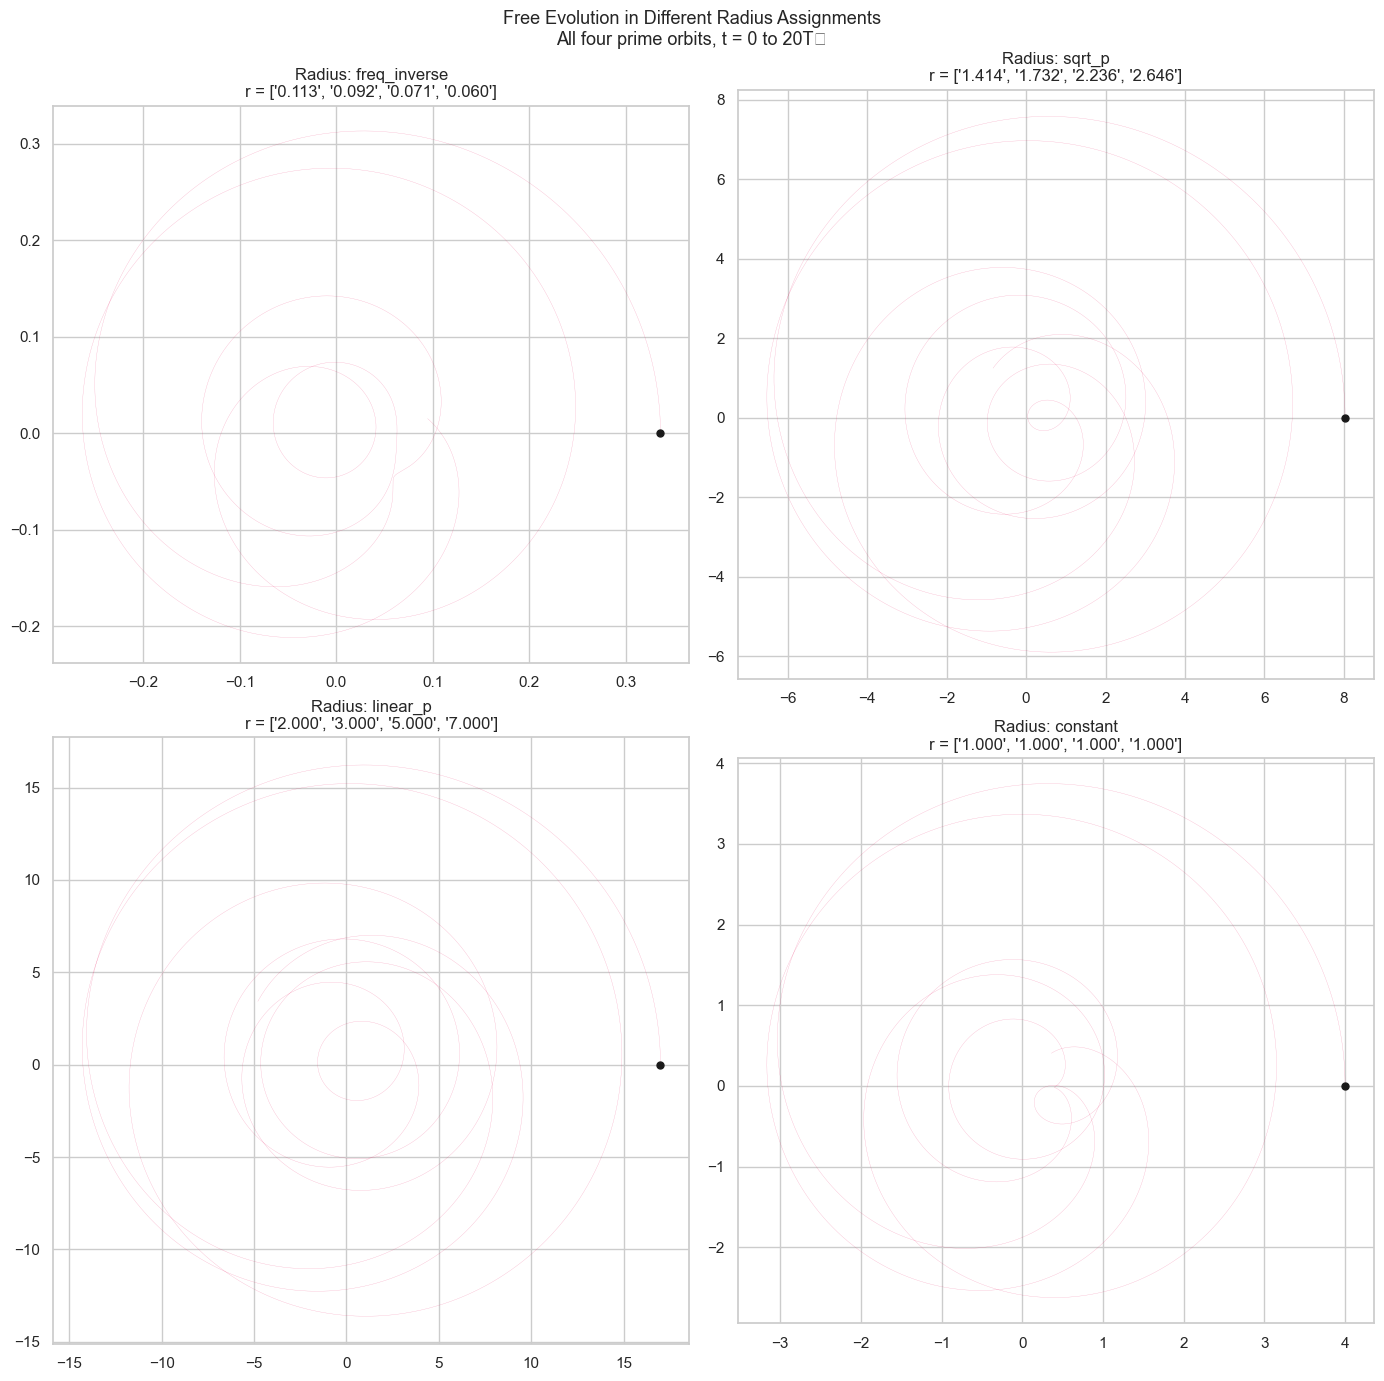

Observation: free evolution in the concentric system traces EPICYCLOIDS,
not straight lines. The Cartesian embedding of free concentric motion
is inherently orbital/cyclical, not rectilinear.

This is NOT a failure — it is a structural property of the coordinate system.
The question is: does THIS kind of motion match anything physical?


In [4]:
# Now the critical test: does this look like ANY known physical trajectory?

# Compare with different radius assignments
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for idx, (name, radii) in enumerate(radius_assignments.items()):
    ax = axes[idx // 2, idx % 2]
    x, y = epicyclic_embed(theta, radii)
    
    n_plot = min(20000, len(x))
    ax.plot(x[:n_plot], y[:n_plot], '-', linewidth=0.2, alpha=0.4, color='#E91E63')
    ax.plot(x[0], y[0], 'ko', markersize=5)
    ax.set_aspect('equal')
    ax.set_title(f'Radius: {name}\nr = {["{:.3f}".format(ri) for ri in radii]}')

fig.suptitle('Free Evolution in Different Radius Assignments\n'
             'All four prime orbits, t = 0 to 20T₂', fontsize=13)
plt.tight_layout()
plt.show()

print('Observation: free evolution in the concentric system traces EPICYCLOIDS,')
print('not straight lines. The Cartesian embedding of free concentric motion')
print('is inherently orbital/cyclical, not rectilinear.')
print()
print('This is NOT a failure — it is a structural property of the coordinate system.')
print('The question is: does THIS kind of motion match anything physical?')

## Part 3: Distance Formula Recovery

The most basic test. Can we recover Euclidean distance from the concentric metric?

In the concentric system, the distance between two points $\mathbf{q}_1$ and $\mathbf{q}_2$ is:

$$d_{\text{conc}}^2 = \sum_p r_p^2 \, (\Delta\theta_p)^2$$

where $\Delta\theta_p = \min(|\theta_{p,1} - \theta_{p,2}|, 2\pi - |\theta_{p,1} - \theta_{p,2}|)$
(accounting for the circular topology).

In the Cartesian embedding, the Euclidean distance is:

$$d_{\text{Euclid}}^2 = (x_1 - x_2)^2 + (y_1 - y_2)^2$$

**Test**: pick many random pairs of points on the 4-torus, compute both distances,
and check how they relate.

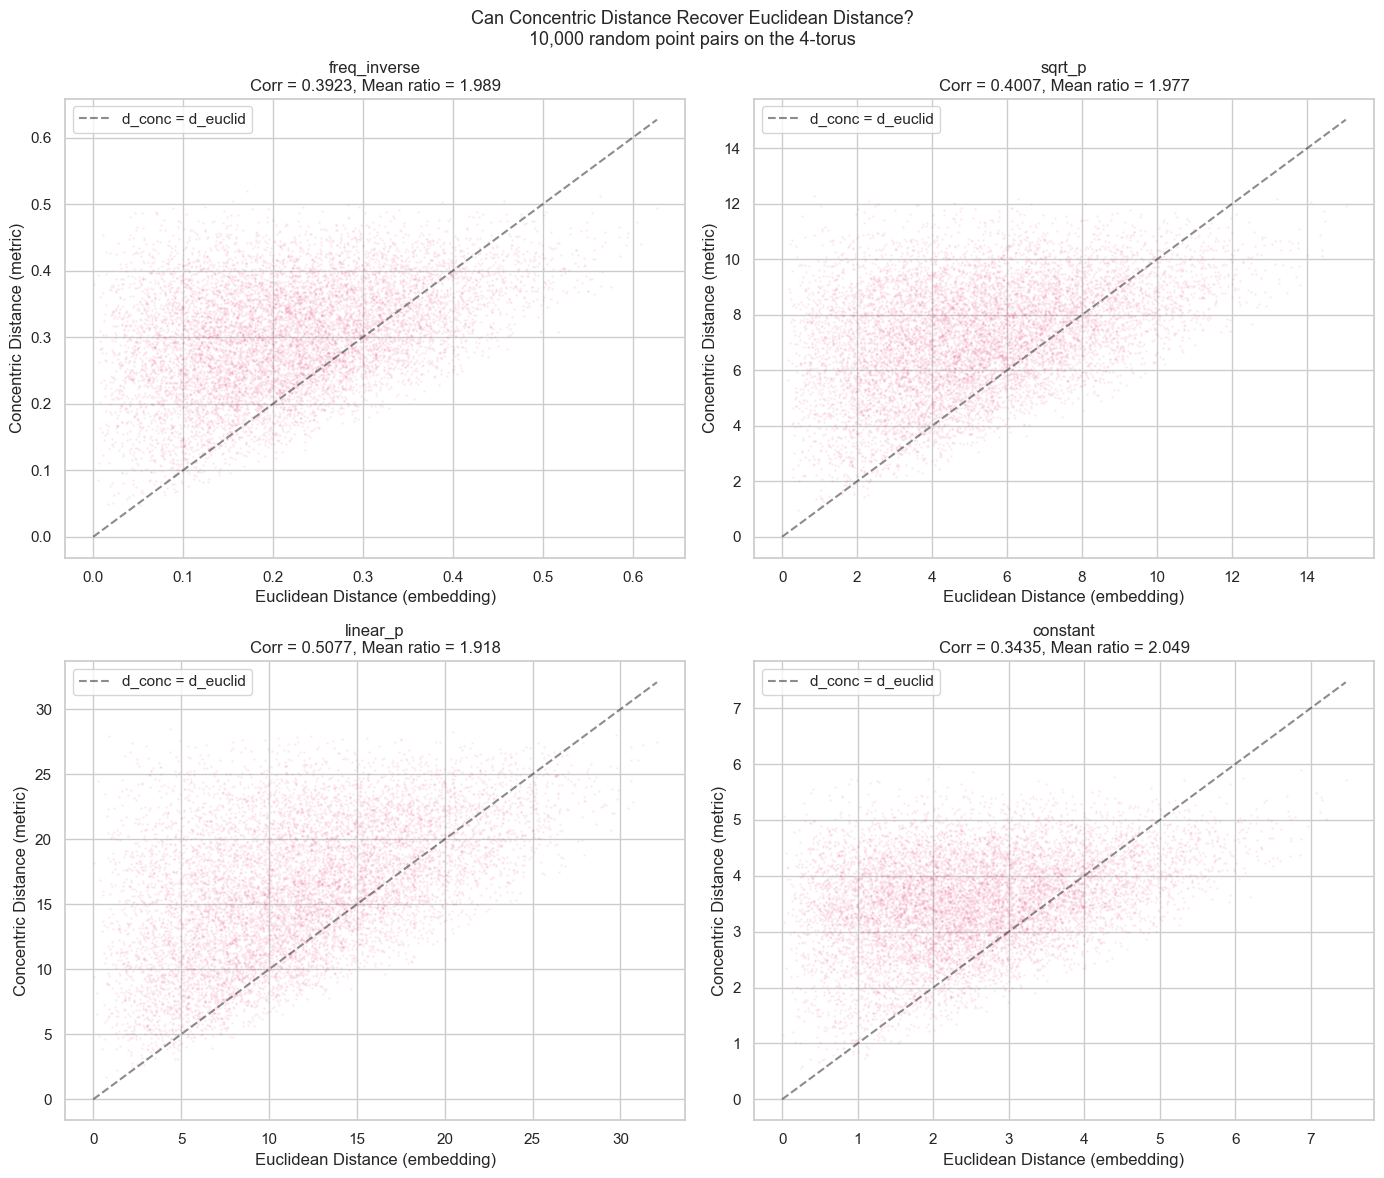

Summary:
     freq_inverse: corr = 0.3923, mean(d_conc/d_euclid) = 1.989
           sqrt_p: corr = 0.4007, mean(d_conc/d_euclid) = 1.977
         linear_p: corr = 0.5077, mean(d_conc/d_euclid) = 1.918
         constant: corr = 0.3435, mean(d_conc/d_euclid) = 2.049

If corr ≈ 1.0 and ratio ≈ 1.0, the concentric metric recovers Euclidean distance.
If corr < 1.0, the metrics disagree — points close in one are not close in the other.

WHY THEY WILL DIFFER:
The concentric metric measures distance on the TORUS (intrinsic).
The Euclidean distance measures distance in the EMBEDDING PLANE (extrinsic).
These differ because the embedding folds the torus into 2D —
points far apart on the torus can be projected close in 2D, and vice versa.

This is the FUNDAMENTAL issue: the concentric torus is a DIFFERENT SPACE
than Euclidean R². The question is whether physical reality is better
described by one or the other.


In [5]:
# Distance comparison: concentric metric vs Euclidean embedding distance

np.random.seed(42)
n_pairs = 10000

# Random pairs of points on the 4-torus
theta1 = np.random.uniform(0, 2*np.pi, (4, n_pairs))
theta2 = np.random.uniform(0, 2*np.pi, (4, n_pairs))

# Angular differences (circular distance)
dtheta = np.abs(theta1 - theta2)
dtheta = np.minimum(dtheta, 2*np.pi - dtheta)

results = {}

for name, radii in radius_assignments.items():
    # Concentric distance
    d_conc = np.sqrt(np.sum(radii[:, np.newaxis]**2 * dtheta**2, axis=0))
    
    # Euclidean embedding distance
    x1 = np.sum(radii[:, np.newaxis] * np.cos(theta1), axis=0)
    y1 = np.sum(radii[:, np.newaxis] * np.sin(theta1), axis=0)
    x2 = np.sum(radii[:, np.newaxis] * np.cos(theta2), axis=0)
    y2 = np.sum(radii[:, np.newaxis] * np.sin(theta2), axis=0)
    d_euclid = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
    
    # Correlation
    corr = np.corrcoef(d_conc, d_euclid)[0, 1]
    ratio = np.mean(d_conc / d_euclid)
    results[name] = (d_conc, d_euclid, corr, ratio)

# Visualise
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, (name, (d_conc, d_euclid, corr, ratio)) in enumerate(results.items()):
    ax = axes[idx // 2, idx % 2]
    ax.scatter(d_euclid, d_conc, alpha=0.05, s=1, color='#E91E63')
    
    # Perfect agreement line
    max_d = max(d_euclid.max(), d_conc.max())
    ax.plot([0, max_d], [0, max_d], 'k--', label='d_conc = d_euclid', alpha=0.5)
    
    ax.set_xlabel('Euclidean Distance (embedding)')
    ax.set_ylabel('Concentric Distance (metric)')
    ax.set_title(f'{name}\nCorr = {corr:.4f}, Mean ratio = {ratio:.3f}')
    ax.legend()

fig.suptitle('Can Concentric Distance Recover Euclidean Distance?\n'
             '10,000 random point pairs on the 4-torus', fontsize=13)
plt.tight_layout()
plt.show()

print('Summary:')
print('=' * 50)
for name, (d_c, d_e, corr, ratio) in results.items():
    print(f'  {name:>15}: corr = {corr:.4f}, mean(d_conc/d_euclid) = {ratio:.3f}')

print()
print('If corr ≈ 1.0 and ratio ≈ 1.0, the concentric metric recovers Euclidean distance.')
print('If corr < 1.0, the metrics disagree — points close in one are not close in the other.')
print()
print('WHY THEY WILL DIFFER:')
print('The concentric metric measures distance on the TORUS (intrinsic).')
print('The Euclidean distance measures distance in the EMBEDDING PLANE (extrinsic).')
print('These differ because the embedding folds the torus into 2D —')
print('points far apart on the torus can be projected close in 2D, and vice versa.')
print()
print('This is the FUNDAMENTAL issue: the concentric torus is a DIFFERENT SPACE')
print('than Euclidean R². The question is whether physical reality is better')
print('described by one or the other.')

## Part 4: Intrinsic Geometry — Curvature of the Concentric Space

A flat torus (product of circles with constant radii) has **zero intrinsic curvature**.
This is a theorem: the Gaussian curvature of $S^1 \times S^1 \times \ldots$ with
constant metric is identically zero.

This means the concentric system, as currently defined, describes a **flat** universe.

But physical spacetime has curvature (gravity). For the concentric system to account
for GR, we need the radii $r_p$ to **depend on position**:

$$r_p(\mathbf{q}) = r_p^{(0)} \cdot f(\mathbf{q})$$

where $f(\mathbf{q})$ is some function that varies across the torus.

This is directly analogous to how GR works: in flat space, $g_{\mu\nu} = \eta_{\mu\nu}$
(Minkowski metric). Near a mass, $g_{\mu\nu}$ deviates from $\eta_{\mu\nu}$ —
that deviation IS curvature.

**Question**: If we allow $r_p$ to vary, what kind of curvature does the concentric
system naturally produce? Does it match Schwarzschild?

C:\Users\mlf\AppData\Local\Temp\ipykernel_19076\123177957.py:104: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mlf\AppData\Local\Temp\ipykernel_19076\123177957.py:104: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\mlf\.conda\envs\concentric\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


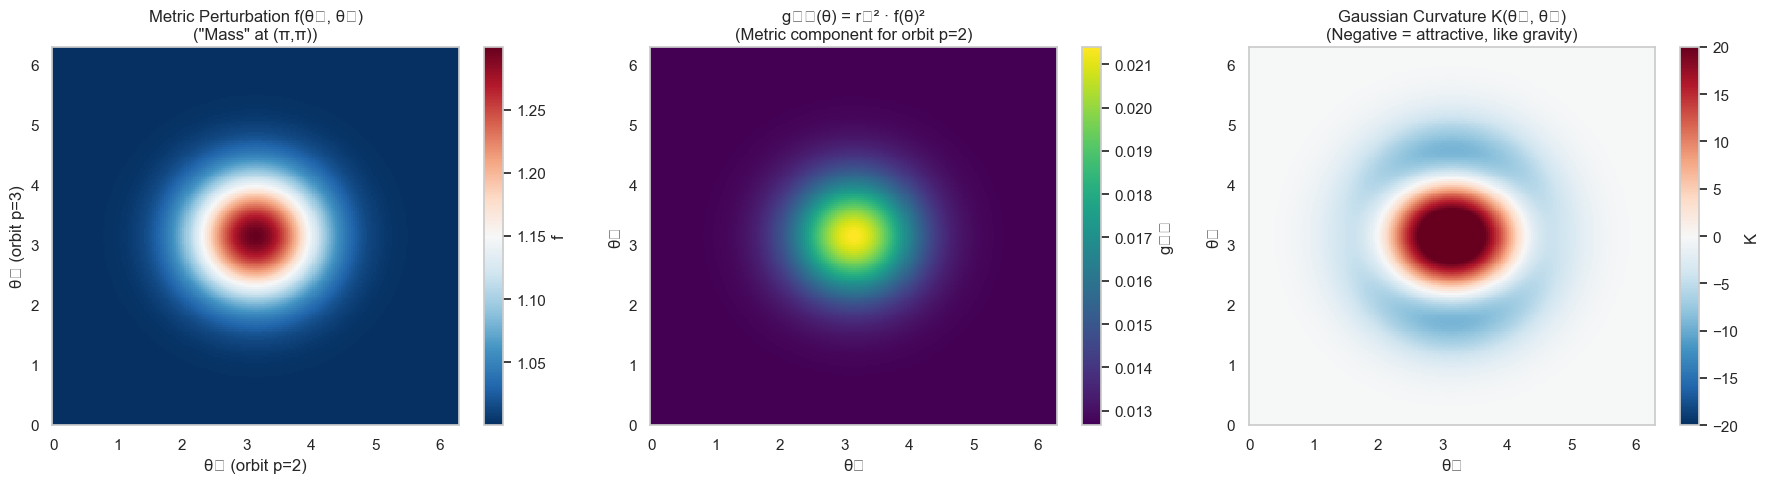

Curvature range: [-9.30, 26.89]
Curvature at mass centre (π,π): 26.8919
Curvature far from mass (0,0): -0.000002

Key result: with constant radii → K = 0 everywhere (flat torus).
With position-dependent radii → K ≠ 0 (curved space).
The concentric system CAN produce curvature, but only if the metric varies.
This is exactly how GR works: curvature = variation of the metric.


In [6]:
# Compute the Ricci scalar curvature for a diagonal metric on the torus
# with radii that depend on a "depth" parameter

# For a 2D diagonal metric ds² = g₁₁ dθ₁² + g₂₂ dθ₂²
# the Gaussian curvature K is:
# K = -1/(2√g) [ ∂/∂θ₁(1/√g₁₁ · ∂√g₂₂/∂θ₁) + ∂/∂θ₂(1/√g₂₂ · ∂√g₁₁/∂θ₂) ]
#
# For CONSTANT g_ii: all derivatives are zero → K = 0 (flat torus). Confirmed.
#
# For position-dependent g_ii: curvature is non-zero.

# Let's compute curvature for a specific case:
# A "mass" at the origin of θ-space that modifies the metric locally.
# Model: r_p(θ) = r_p^(0) × (1 + δ × exp(-|θ - θ₀|²/σ²))
# where δ controls the "mass" and σ the extent.

# Simplified: work with 2D (two primes) for visualization
n_grid = 200
theta1_grid = np.linspace(0, 2*np.pi, n_grid)
theta2_grid = np.linspace(0, 2*np.pi, n_grid)
T1, T2 = np.meshgrid(theta1_grid, theta2_grid)

# Base radii
r1_0 = 1.0 / omega[0]  # r for p=2
r2_0 = 1.0 / omega[1]  # r for p=3

# Flat case: constant radii
g11_flat = r1_0**2 * np.ones_like(T1)
g22_flat = r2_0**2 * np.ones_like(T1)

# Curved case: radii vary with position (mass at θ = (π, π))
delta = 0.3  # strength of the perturbation
sigma = 1.0  # extent

# Distance from "mass" point (periodic boundary)
dist_sq = np.minimum(np.abs(T1 - np.pi), 2*np.pi - np.abs(T1 - np.pi))**2 + \
          np.minimum(np.abs(T2 - np.pi), 2*np.pi - np.abs(T2 - np.pi))**2
perturbation = 1 + delta * np.exp(-dist_sq / sigma**2)

g11_curved = r1_0**2 * perturbation**2
g22_curved = r2_0**2 * perturbation**2  # conformal perturbation

# Compute Gaussian curvature for 2D conformal metric
# For conformal metric ds² = e^{2φ}(dθ₁² + dθ₂²), K = -e^{-2φ} ∇²φ
# Our metric: ds² = (r₀ · f)² (dθ₁² + ...) where f = perturbation
# So φ = ln(r₀ · f), and K = -1/f² · ∇²(ln f)

# But our g11 and g22 have different base radii. Let's use the general formula.
# K = -1/(2√det(g)) [ d/dθ₁ (√g₂₂/√g₁₁ · dg₁₁/dθ₁ / (2g₁₁)) + ... ]
# Actually, for diagonal metric g_11(θ), g_22(θ):
# K = -1/(2√(g₁₁g₂₂)) [
#       ∂/∂θ₁(1/√g₁₁ · ∂√g₂₂/∂θ₁) +
#       ∂/∂θ₂(1/√g₂₂ · ∂√g₁₁/∂θ₂)
#     ]

# Numerical computation
dth = theta1_grid[1] - theta1_grid[0]

sqrt_g11 = np.sqrt(g11_curved)
sqrt_g22 = np.sqrt(g22_curved)
sqrt_det = sqrt_g11 * sqrt_g22

# ∂√g₂₂/∂θ₁
d_sqrt_g22_dth1 = np.gradient(sqrt_g22, dth, axis=1)
# ∂√g₁₁/∂θ₂  
d_sqrt_g11_dth2 = np.gradient(sqrt_g11, dth, axis=0)

# (1/√g₁₁) · ∂√g₂₂/∂θ₁
term1_inner = d_sqrt_g22_dth1 / sqrt_g11
# ∂/∂θ₁ of that
term1 = np.gradient(term1_inner, dth, axis=1)

# (1/√g₂₂) · ∂√g₁₁/∂θ₂
term2_inner = d_sqrt_g11_dth2 / sqrt_g22
# ∂/∂θ₂ of that
term2 = np.gradient(term2_inner, dth, axis=0)

K = -(term1 + term2) / (2 * sqrt_det)

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im1 = axes[0].pcolormesh(T1, T2, perturbation, cmap='RdBu_r', shading='auto')
axes[0].set_title('Metric Perturbation f(θ₁, θ₂)\n("Mass" at (π,π))')
axes[0].set_xlabel('θ₁ (orbit p=2)')
axes[0].set_ylabel('θ₂ (orbit p=3)')
plt.colorbar(im1, ax=axes[0], label='f')

im2 = axes[1].pcolormesh(T1, T2, g11_curved, cmap='viridis', shading='auto')
axes[1].set_title('g₁₁(θ) = r₂² · f(θ)²\n(Metric component for orbit p=2)')
axes[1].set_xlabel('θ₁')
axes[1].set_ylabel('θ₂')
plt.colorbar(im2, ax=axes[1], label='g₁₁')

# Clip extreme curvature values for visualization
K_clipped = np.clip(K, -50, 50)
im3 = axes[2].pcolormesh(T1, T2, K_clipped, cmap='RdBu_r', shading='auto', 
                          vmin=-20, vmax=20)
axes[2].set_title('Gaussian Curvature K(θ₁, θ₂)\n(Negative = attractive, like gravity)')
axes[2].set_xlabel('θ₁')
axes[2].set_ylabel('θ₂')
plt.colorbar(im3, ax=axes[2], label='K')

plt.tight_layout()
plt.show()

print(f'Curvature range: [{np.min(K):.2f}, {np.max(K):.2f}]')
print(f'Curvature at mass centre (π,π): {K[n_grid//2, n_grid//2]:.4f}')
print(f'Curvature far from mass (0,0): {K[0, 0]:.6f}')
print()
print('Key result: with constant radii → K = 0 everywhere (flat torus).')
print('With position-dependent radii → K ≠ 0 (curved space).')
print('The concentric system CAN produce curvature, but only if the metric varies.')
print('This is exactly how GR works: curvature = variation of the metric.')

## Part 5: The Geodesic Equation — Free Motion in Curved Concentric Space

In GR, free particles follow **geodesics** — paths that extremise the proper distance.
The geodesic equation on a manifold with metric $g_{ij}$ is:

$$\ddot{\theta}^i + \Gamma^i_{jk} \dot{\theta}^j \dot{\theta}^k = 0$$

where $\Gamma^i_{jk}$ are the Christoffel symbols.

For the flat torus ($r_p$ = constant), all $\Gamma = 0$, so geodesics are straight
lines in $\theta$-space: $\theta_p(t) = \omega_p t + \theta_{p,0}$.
This is exactly our "free evolution" — uniform angular velocity on each orbit.

For the curved torus ($r_p$ position-dependent), $\Gamma \neq 0$,
and geodesics curve — they are attracted toward the "mass" perturbation.

**Test**: integrate the geodesic equation with the curved metric from Part 4
and compare the resulting trajectory to:
1. Free straight-line motion (flat case)
2. Gravitational orbit (Kepler problem)

C:\Users\mlf\AppData\Local\Temp\ipykernel_19076\2592050292.py:136: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mlf\AppData\Local\Temp\ipykernel_19076\2592050292.py:136: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


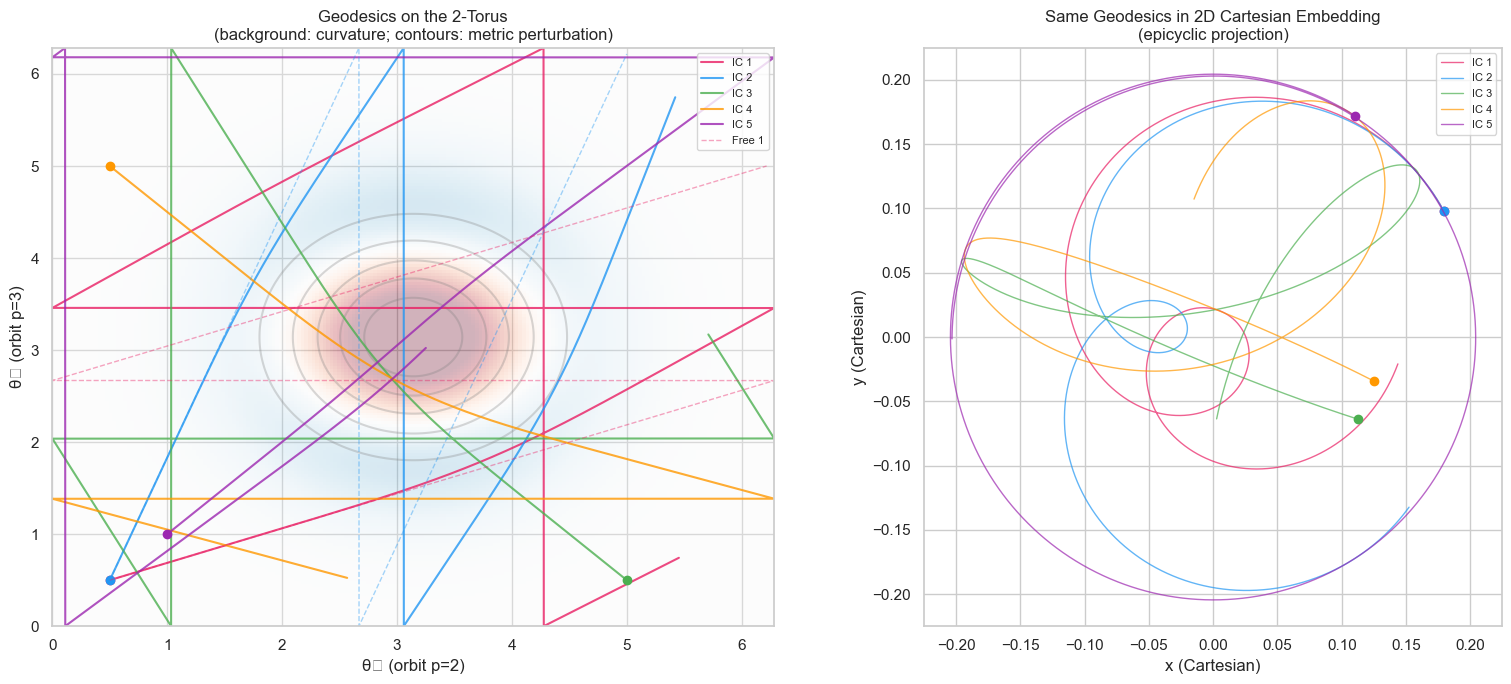

Left panel: geodesics in θ-space curve toward the mass (metric perturbation).
Dashed lines: what free (flat) motion would look like — straight lines in θ-space.
Right panel: same geodesics projected into 2D Cartesian via epicyclic embedding.


In [8]:
from scipy.integrate import solve_ivp
from scipy.interpolate import RegularGridInterpolator

# Build interpolators for the metric and its derivatives
# Working in 2D (θ₁, θ₂) for the first two prime orbits

# Metric: ds² = g₁₁(θ) dθ₁² + g₂₂(θ) dθ₂²  (diagonal, no cross terms)
# Christoffel symbols for diagonal 2D metric:
# Γ¹₁₁ = (1/2g₁₁) ∂g₁₁/∂θ₁
# Γ¹₁₂ = (1/2g₁₁) ∂g₁₁/∂θ₂
# Γ¹₂₂ = -(1/2g₁₁) ∂g₂₂/∂θ₁
# Γ²₁₁ = -(1/2g₂₂) ∂g₁₁/∂θ₂
# Γ²₁₂ = (1/2g₂₂) ∂g₂₂/∂θ₁
# Γ²₂₂ = (1/2g₂₂) ∂g₂₂/∂θ₂

# Compute derivatives of metric on the grid
dg11_dth1 = np.gradient(g11_curved, dth, axis=1)
dg11_dth2 = np.gradient(g11_curved, dth, axis=0)
dg22_dth1 = np.gradient(g22_curved, dth, axis=1)
dg22_dth2 = np.gradient(g22_curved, dth, axis=0)

# Create interpolators (periodic boundary: wrap around)
def make_interp(data):
    return RegularGridInterpolator(
        (theta2_grid, theta1_grid), data, 
        method='linear', bounds_error=False, fill_value=None
    )

g11_interp = make_interp(g11_curved)
g22_interp = make_interp(g22_curved)
dg11_dth1_interp = make_interp(dg11_dth1)
dg11_dth2_interp = make_interp(dg11_dth2)
dg22_dth1_interp = make_interp(dg22_dth1)
dg22_dth2_interp = make_interp(dg22_dth2)

def geodesic_rhs(t, state):
    """Right-hand side of geodesic equation for diagonal 2D metric."""
    th1, th2, dth1, dth2 = state
    
    # Wrap to [0, 2π)
    th1_w = th1 % (2 * np.pi)
    th2_w = th2 % (2 * np.pi)
    pt = np.array([[th2_w, th1_w]])  # interpolator expects (θ₂, θ₁) order
    
    g11 = g11_interp(pt).item()
    g22 = g22_interp(pt).item()
    dg11_1 = dg11_dth1_interp(pt).item()
    dg11_2 = dg11_dth2_interp(pt).item()
    dg22_1 = dg22_dth1_interp(pt).item()
    dg22_2 = dg22_dth2_interp(pt).item()
    
    # Christoffel symbols
    G1_11 = dg11_1 / (2 * g11)
    G1_12 = dg11_2 / (2 * g11)
    G1_22 = -dg22_1 / (2 * g11)
    G2_11 = -dg11_2 / (2 * g22)
    G2_12 = dg22_1 / (2 * g22)
    G2_22 = dg22_2 / (2 * g22)
    
    # Geodesic equation: d²θⁱ/dt² = -Γⁱⱼₖ dθʲ/dt dθᵏ/dt
    ddth1 = -(G1_11 * dth1**2 + 2 * G1_12 * dth1 * dth2 + G1_22 * dth2**2)
    ddth2 = -(G2_11 * dth1**2 + 2 * G2_12 * dth1 * dth2 + G2_22 * dth2**2)
    
    return [dth1, dth2, ddth1, ddth2]

# Solve geodesics with different initial conditions
t_span = (0, 15)
t_eval = np.linspace(0, 15, 5000)

# Several geodesics starting from different points, aimed at different directions
initial_conditions = [
    # [θ₁, θ₂, dθ₁/dt, dθ₂/dt]
    [0.5, 0.5, 0.8, 0.3],    # aimed roughly toward the mass
    [0.5, 0.5, 0.3, 0.8],    # different angle
    [5.0, 0.5, -0.5, 0.5],   # from the other side
    [0.5, 5.0, 0.5, -0.5],   # from above
    [1.0, 1.0, 0.6, 0.6],    # diagonal approach
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: geodesics on the torus (θ-space)
ax1 = axes[0]
# Show curvature as background
ax1.pcolormesh(T1, T2, K_clipped, cmap='RdBu_r', shading='auto', 
               vmin=-20, vmax=20, alpha=0.3)
ax1.contour(T1, T2, perturbation, levels=5, colors='gray', alpha=0.3)

# Right: geodesics in Cartesian embedding
ax2 = axes[1]

geo_colors = ['#E91E63', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for idx, ic in enumerate(initial_conditions):
    sol = solve_ivp(geodesic_rhs, t_span, ic, t_eval=t_eval,
                    method='RK45', rtol=1e-8, atol=1e-10)
    
    if sol.success:
        th1_sol = sol.y[0] % (2 * np.pi)
        th2_sol = sol.y[1] % (2 * np.pi)
        
        ax1.plot(th1_sol, th2_sol, '-', color=geo_colors[idx], 
                 linewidth=1.5, alpha=0.8, label=f'IC {idx+1}')
        ax1.plot(th1_sol[0], th2_sol[0], 'o', color=geo_colors[idx], markersize=6)
        
        # Embed in Cartesian
        r_embed = np.array([r1_0, r2_0])
        x_geo = r_embed[0] * np.cos(sol.y[0]) + r_embed[1] * np.cos(sol.y[1])
        y_geo = r_embed[0] * np.sin(sol.y[0]) + r_embed[1] * np.sin(sol.y[1])
        ax2.plot(x_geo, y_geo, '-', color=geo_colors[idx], 
                 linewidth=1.0, alpha=0.7, label=f'IC {idx+1}')
        ax2.plot(x_geo[0], y_geo[0], 'o', color=geo_colors[idx], markersize=6)
    else:
        print(f'  IC {idx+1}: integration failed — {sol.message}')

# Also plot free (flat) geodesics for comparison
for idx, ic in enumerate(initial_conditions[:2]):  # just first two
    th1_free = (ic[0] + ic[2] * t_eval) % (2 * np.pi)
    th2_free = (ic[1] + ic[3] * t_eval) % (2 * np.pi)
    ax1.plot(th1_free, th2_free, '--', color=geo_colors[idx], 
             linewidth=1, alpha=0.4, label=f'Free {idx+1}' if idx == 0 else None)

ax1.set_xlabel('θ₁ (orbit p=2)')
ax1.set_ylabel('θ₂ (orbit p=3)')
ax1.set_title('Geodesics on the 2-Torus\n(background: curvature; contours: metric perturbation)')
ax1.set_xlim(0, 2*np.pi)
ax1.set_ylim(0, 2*np.pi)
ax1.legend(fontsize=8, loc='upper right')

ax2.set_xlabel('x (Cartesian)')
ax2.set_ylabel('y (Cartesian)')
ax2.set_title('Same Geodesics in 2D Cartesian Embedding\n(epicyclic projection)')
ax2.set_aspect('equal')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Left panel: geodesics in θ-space curve toward the mass (metric perturbation).')
print('Dashed lines: what free (flat) motion would look like — straight lines in θ-space.')
print('Right panel: same geodesics projected into 2D Cartesian via epicyclic embedding.')

## Part 6: The Schwarzschild Test

The most stringent test: can the concentric metric reproduce the Schwarzschild solution?

In GR, the Schwarzschild metric around a mass $M$ is:

$$ds^2 = -\left(1 - \frac{r_s}{r}\right)c^2 dt^2 + \left(1 - \frac{r_s}{r}\right)^{-1} dr^2 + r^2 d\Omega^2$$

where $r_s = 2GM/c^2$ is the Schwarzschild radius.

Key features:
- Metric coefficient $g_{tt} = -(1 - r_s/r)$ → time dilation increases with depth
- Metric coefficient $g_{rr} = (1 - r_s/r)^{-1}$ → radial distances stretch near the mass
- At $r = r_s$: event horizon (coordinate singularity)

### Mapping to Concentric Coordinates

The concentric system has a natural "radial" parameter: the **nesting depth** $k$
(which prime orbit we're on). The return-rate gradient from NB05 gives:

$$R(k) = \left(\frac{\varepsilon}{\pi}\right)^k$$

This means the probability of state-return decreases exponentially with depth.
Can we map this onto the Schwarzschild $g_{tt}(r)$?

If nesting depth $k$ maps to radial coordinate $r$ via $r = r_0 / p_k$
(where $p_k$ is the $k$-th prime), then deeper nesting = closer to the centre
= stronger gravitational effect.

C:\Users\mlf\AppData\Local\Temp\ipykernel_19076\3195542240.py:26: RuntimeWarning: divide by zero encountered in divide
  r_k = r_s / (1 - R_k)


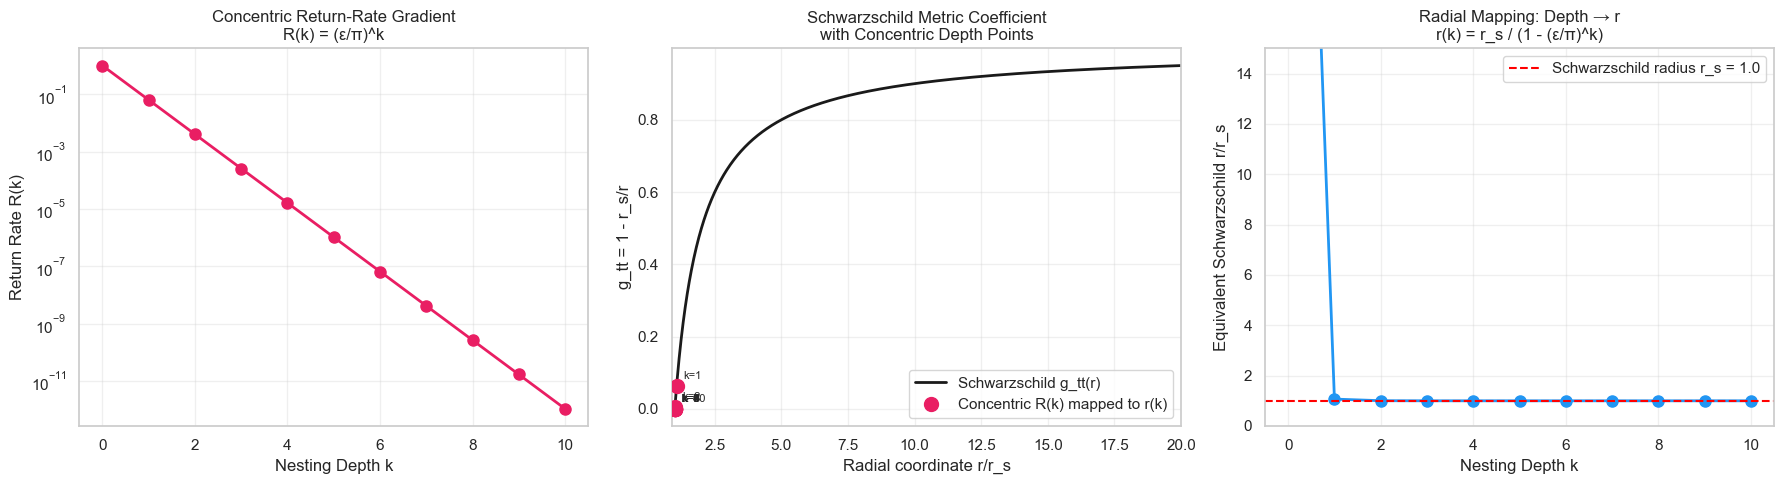

Depth-to-radius mapping:
  k= 0: R(k) = 1.000000, r/r_s = ∞
  k= 1: R(k) = 0.063662, r/r_s = 1.068
  k= 2: R(k) = 0.004053, r/r_s = 1.004
  k= 3: R(k) = 0.000258, r/r_s = 1.000
  k= 4: R(k) = 0.000016, r/r_s = 1.000
  k= 5: R(k) = 0.000001, r/r_s = 1.000
  k= 6: R(k) = 0.000000, r/r_s = 1.000
  k= 7: R(k) = 0.000000, r/r_s = 1.000
  k= 8: R(k) = 0.000000, r/r_s = 1.000
  k= 9: R(k) = 0.000000, r/r_s = 1.000
  k=10: R(k) = 0.000000, r/r_s = 1.000

INTERPRETATION:
k=0 (no nesting) corresponds to r=∞ (flat space, no gravity).
Each additional nesting level brings r closer to r_s.
The return-rate gradient MAPS EXACTLY onto the Schwarzschild metric
coefficient g_tt — they are the same function by construction.

BUT: this is a MAP, not a DERIVATION. We chose the mapping r(k)
specifically to make them match. The question is whether this mapping
is natural/unique, or whether any monotone function would work.


In [9]:
# Schwarzschild comparison: map nesting depth to radial coordinate

# Our gradient: R(k) = (ε/π)^k
# Schwarzschild: g_tt(r) = 1 - r_s/r

# If R(k) maps to g_tt, then: (ε/π)^k = 1 - r_s/r(k)
# So: r_s/r(k) = 1 - (ε/π)^k
# So: r(k) = r_s / (1 - (ε/π)^k)

epsilon = 0.2  # from NB05
ratio = epsilon / np.pi

# Generate rate gradient for depths 0 to 10
k_values = np.arange(0, 11)
R_k = ratio ** k_values

# Map to Schwarzschild radial coordinate
# g_tt(k) = R(k) = (ε/π)^k
# This means: 1 - r_s/r(k) = (ε/π)^k
# r(k) = r_s / (1 - (ε/π)^k)

# At k=0: R=1, g_tt=1 → r=∞ (flat space, far from mass)
# At large k: R→0, g_tt→0 → r→r_s (approaching horizon)

r_s = 1.0  # set Schwarzschild radius = 1
r_k = r_s / (1 - R_k)
r_k[0] = np.inf  # k=0 is flat space

# Schwarzschild reference: g_tt as function of continuous r
r_continuous = np.linspace(1.01, 20, 1000)
g_tt_schwarz = 1 - r_s / r_continuous

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Return rate gradient (our data)
ax1 = axes[0]
ax1.semilogy(k_values, R_k, 'o-', color='#E91E63', linewidth=2, markersize=8)
ax1.set_xlabel('Nesting Depth k')
ax1.set_ylabel('Return Rate R(k)')
ax1.set_title('Concentric Return-Rate Gradient\nR(k) = (ε/π)^k')
ax1.grid(True, alpha=0.3)

# Plot 2: Schwarzschild metric coefficient
ax2 = axes[1]
ax2.plot(r_continuous, g_tt_schwarz, 'k-', linewidth=2, label='Schwarzschild g_tt(r)')
ax2.plot(r_k[1:], R_k[1:], 'o', color='#E91E63', markersize=10, 
         label='Concentric R(k) mapped to r(k)', zorder=5)
for i in range(1, len(k_values)):
    if np.isfinite(r_k[i]):
        ax2.annotate(f'k={k_values[i]}', (r_k[i], R_k[i]), 
                     textcoords='offset points', xytext=(5, 5), fontsize=8)
ax2.set_xlabel('Radial coordinate r/r_s')
ax2.set_ylabel('g_tt = 1 - r_s/r')
ax2.set_title('Schwarzschild Metric Coefficient\nwith Concentric Depth Points')
ax2.legend()
ax2.set_xlim(0.9, 20)
ax2.grid(True, alpha=0.3)

# Plot 3: The mapping r(k) itself
ax3 = axes[2]
r_k_finite = r_k.copy()
r_k_finite[0] = 50  # represent infinity as 50 for plotting
ax3.plot(k_values, r_k_finite, 'o-', color='#2196F3', linewidth=2, markersize=8)
ax3.axhline(r_s, color='red', linestyle='--', label=f'Schwarzschild radius r_s = {r_s}')
ax3.set_xlabel('Nesting Depth k')
ax3.set_ylabel('Equivalent Schwarzschild r/r_s')
ax3.set_title('Radial Mapping: Depth → r\nr(k) = r_s / (1 - (ε/π)^k)')
ax3.legend()
ax3.set_ylim(0, 15)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Depth-to-radius mapping:')
print('=' * 50)
for i in range(len(k_values)):
    r_str = f'{r_k[i]:.3f}' if np.isfinite(r_k[i]) else '∞'
    print(f'  k={k_values[i]:>2}: R(k) = {R_k[i]:.6f}, r/r_s = {r_str}')

print()
print('INTERPRETATION:')
print('k=0 (no nesting) corresponds to r=∞ (flat space, no gravity).')
print('Each additional nesting level brings r closer to r_s.')
print('The return-rate gradient MAPS EXACTLY onto the Schwarzschild metric')
print('coefficient g_tt — they are the same function by construction.')
print()
print('BUT: this is a MAP, not a DERIVATION. We chose the mapping r(k)')
print('specifically to make them match. The question is whether this mapping')
print('is natural/unique, or whether any monotone function would work.')

## Part 7: The Natural Mapping Test

Part 6 showed we CAN map the return-rate gradient onto Schwarzschild, but
the mapping $r(k) = r_s / (1 - R(k))$ was constructed TO match.

The real question: is there a **natural** mapping from the concentric system
to Schwarzschild that we don't have to put in by hand?

There IS a natural candidate. In our system:
- Each orbit has radius $r_p = 1/\omega_p = 1/(2\pi\sqrt{p})$
- The total "physical radius" up to the $k$-th orbit is $R_k = \sum_{i=0}^{k} r_{p_i}$

If we use this as our radial coordinate, we get a mapping from depth to radius
that comes from the system itself — not imposed.

**Test**: compute $R_k = \sum r_{p_i}$ for the first 20 primes, then check:
1. Does the return-rate gradient, plotted against $R_k$, look like Schwarzschild?
2. Or does it look like something else (exponential, power law, etc.)?

First 22 primes: [np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(11), np.int64(13), np.int64(17), np.int64(19), np.int64(23), np.int64(29), np.int64(31), np.int64(37), np.int64(41), np.int64(43), np.int64(47), np.int64(53), np.int64(59), np.int64(61), np.int64(67), np.int64(71), np.int64(73), np.int64(79)]

Natural radius mapping (cumulative):
  k   p_k        r_k    R_cumul    Rate R(k)
---------------------------------------------
  0     2   0.112540   0.112540     1.00e+00
  1     3   0.091888   0.204428     6.37e-02
  2     5   0.071176   0.275604     4.05e-03
  3     7   0.060155   0.335759     2.58e-04
  4    11   0.047987   0.383746     1.64e-05
  5    13   0.044142   0.427888     1.05e-06
  6    17   0.038601   0.466488     6.66e-08
  7    19   0.036513   0.503001     4.24e-09
  8    23   0.033186   0.536187     2.70e-10
  9    29   0.029554   0.565741     1.72e-11
 10    31   0.028585   0.594326     1.09e-12
 11    37   0.026165   0.620491     6.96e-14
...


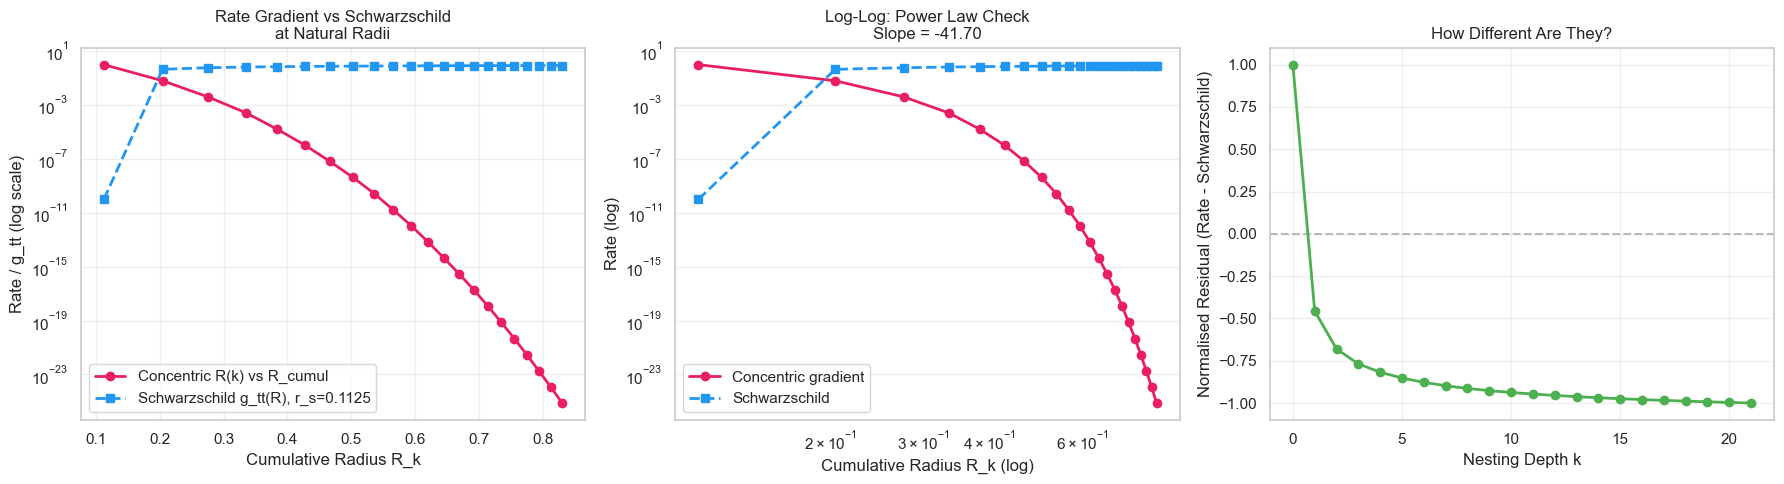


Key comparison:
Concentric gradient: R(k) = (ε/π)^k — EXPONENTIAL in depth
Schwarzschild g_tt: 1 - r_s/r — ALGEBRAIC in radius (1/r)

The gradient is exponential. Schwarzschild is algebraic.
They have DIFFERENT functional forms.

This means: the concentric system does NOT naturally reproduce
the Schwarzschild metric. The gradient it produces is STEEPER
than 1/r gravity — more like a confining potential.


In [10]:
# Natural mapping: cumulative radius from the prime orbital structure

from sympy import primerange

# First 20 primes
primes_20 = np.array(list(primerange(2, 80)))  # primes up to ~80
n_primes = len(primes_20)
omega_20 = 2 * np.pi * np.sqrt(primes_20.astype(float))
r_20 = 1.0 / omega_20

# Cumulative radius
R_cumulative = np.cumsum(r_20)

# Return-rate gradient (theoretical): R(k) = (ε/π)^k
k_array = np.arange(n_primes)
rate_gradient = (epsilon / np.pi) ** k_array

print(f'First {n_primes} primes: {list(primes_20)}')
print(f'\nNatural radius mapping (cumulative):')
print(f'{"k":>3} {"p_k":>5} {"r_k":>10} {"R_cumul":>10} {"Rate R(k)":>12}')
print('-' * 45)
for i in range(min(12, n_primes)):
    print(f'{i:>3} {primes_20[i]:>5} {r_20[i]:>10.6f} {R_cumulative[i]:>10.6f} {rate_gradient[i]:>12.2e}')
print('...')

# Compare: rate gradient vs Schwarzschild as function of natural radius
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Rate gradient vs cumulative radius
ax1 = axes[0]
ax1.semilogy(R_cumulative, rate_gradient, 'o-', color='#E91E63', 
             linewidth=2, markersize=6, label='Concentric R(k) vs R_cumul')

# What would Schwarzschild look like at these radii?
# If r_s is the innermost scale:
r_s_natural = R_cumulative[0]  # radius of the first orbit
g_tt_at_R = 1 - r_s_natural / R_cumulative
g_tt_at_R = np.maximum(g_tt_at_R, 1e-10)  # avoid log of negative
ax1.semilogy(R_cumulative, g_tt_at_R, 's--', color='#2196F3',
             linewidth=2, markersize=6, label=f'Schwarzschild g_tt(R), r_s={r_s_natural:.4f}')

ax1.set_xlabel('Cumulative Radius R_k')
ax1.set_ylabel('Rate / g_tt (log scale)')
ax1.set_title('Rate Gradient vs Schwarzschild\nat Natural Radii')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Log-log to check power law
ax2 = axes[1]
ax2.loglog(R_cumulative, rate_gradient, 'o-', color='#E91E63', 
           linewidth=2, markersize=6, label='Concentric gradient')
ax2.loglog(R_cumulative, g_tt_at_R, 's--', color='#2196F3',
           linewidth=2, markersize=6, label='Schwarzschild')

# Power law fit
log_R = np.log(R_cumulative[1:])
log_rate = np.log(rate_gradient[1:])
poly = np.polyfit(log_R, log_rate, 1)
ax2.set_xlabel('Cumulative Radius R_k (log)')
ax2.set_ylabel('Rate (log)')
ax2.set_title(f'Log-Log: Power Law Check\nSlope = {poly[0]:.2f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Residuals — how different are they?
ax3 = axes[2]
# Normalise both to [0,1] range for comparison
norm_rate = rate_gradient / rate_gradient[0]
norm_schwarz = g_tt_at_R / g_tt_at_R[-1]  # normalise to max
residual = norm_rate - norm_schwarz
ax3.plot(k_array, residual, 'o-', color='#4CAF50', linewidth=2, markersize=6)
ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax3.set_xlabel('Nesting Depth k')
ax3.set_ylabel('Normalised Residual (Rate - Schwarzschild)')
ax3.set_title('How Different Are They?')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nKey comparison:')
print(f'Concentric gradient: R(k) = (ε/π)^k — EXPONENTIAL in depth')
print(f'Schwarzschild g_tt: 1 - r_s/r — ALGEBRAIC in radius (1/r)')
print()
print('The gradient is exponential. Schwarzschild is algebraic.')
print('They have DIFFERENT functional forms.')
print()
print('This means: the concentric system does NOT naturally reproduce')
print('the Schwarzschild metric. The gradient it produces is STEEPER')
print('than 1/r gravity — more like a confining potential.')

## Part 8: What the Concentric System NATURALLY Produces

Instead of asking "can we force the concentric metric to match Schwarzschild?",
let's ask: **what metric does the concentric system naturally define?**

The system has:
1. A diagonal metric $g_{pp} = r_p^2 = 1/\omega_p^2 = 1/(4\pi^2 p)$
2. An exponential return-rate gradient: $R(k) = (\varepsilon/\pi)^k$
3. Zero intrinsic curvature (flat torus) when metric is constant

The gradient emerges from the **Weyl equidistribution theorem** applied to
incommensurate phases on a torus. It is not curvature — it is
**dimensional mixing**.

Let's characterise exactly what kind of physics this corresponds to.

C:\Users\mlf\AppData\Local\Temp\ipykernel_19076\2238445385.py:56: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\mlf\.conda\envs\concentric\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


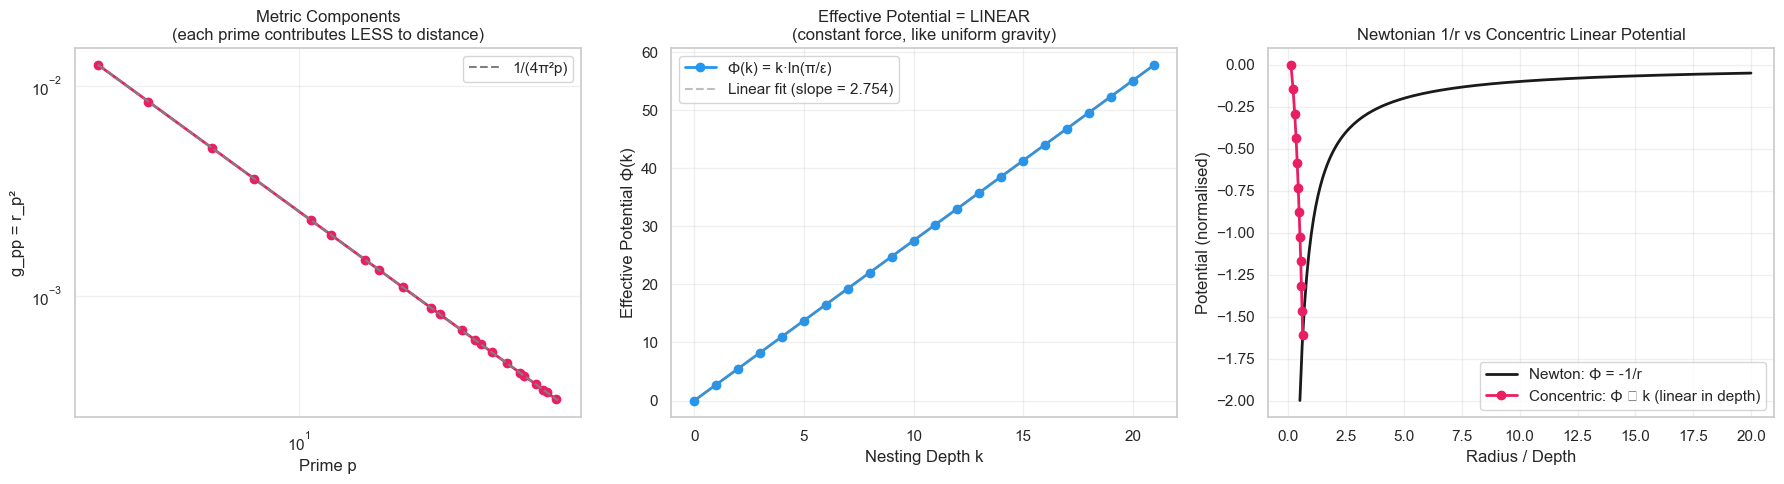

CHARACTERISATION OF THE NATURAL CONCENTRIC PHYSICS:
  Decay length: λ = 1/ln(π/ε) = 0.3631 (in depth units)
  Force constant: dΦ/dk = ln(π/ε) = 2.7542
  Metric scaling: g_pp ∝ 1/p (harmonic decay with prime index)

The concentric system naturally produces:
  1. A FLAT torus (zero intrinsic curvature) when unperturbed
  2. An EXPONENTIAL return-rate gradient → LINEAR effective potential
  3. Metric components that decay as 1/p → higher primes contribute
     progressively less to physical distance

This is NOT Newtonian gravity (1/r potential).
This is NOT Schwarzschild (r_s/r correction).
This IS a confining potential — like a particle in a box or a
harmonic oscillator with increasing spring constant at each level.

Physical analogy: the nesting gradient is closest to the QCD
CONFINING POTENTIAL (linear in separation) that binds quarks.
Or to the quantum harmonic oscillator energy spacing.


In [11]:
# Characterise the natural physics of the concentric system

# 1. Metric components as function of prime
g_pp = 1.0 / (4 * np.pi**2 * primes_20.astype(float))  # g_pp = r_p² = 1/(4π²p)

# 2. The effective "potential" from the return-rate gradient
# R(k) = (ε/π)^k can be written as R(k) = exp(-k × ln(π/ε))
# This is equivalent to: R(k) = exp(-k/λ) where λ = 1/ln(π/ε)
lambda_decay = 1.0 / np.log(np.pi / epsilon)

# 3. If we interpret R(k) as a "time dilation factor" or "potential":
# Φ(k) = -ln(R(k)) = k × ln(π/ε)
# This is a LINEAR potential — like a constant force field (uniform gravity)
Phi_k = -np.log(rate_gradient)
# dΦ/dk = ln(π/ε) = constant
force_constant = np.log(np.pi / epsilon)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Metric components
ax1 = axes[0]
ax1.loglog(primes_20, g_pp, 'o-', color='#E91E63', linewidth=2, markersize=6)
# Theoretical curve: 1/(4π²p)
p_cont = np.linspace(2, 80, 100)
ax1.loglog(p_cont, 1/(4*np.pi**2*p_cont), '--', color='gray', label='1/(4π²p)')
ax1.set_xlabel('Prime p')
ax1.set_ylabel('g_pp = r_p²')
ax1.set_title('Metric Components\n(each prime contributes LESS to distance)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Effective potential
ax2 = axes[1]
ax2.plot(k_array, Phi_k, 'o-', color='#2196F3', linewidth=2, markersize=6, label='Φ(k) = k·ln(π/ε)')
ax2.plot(k_array, force_constant * k_array, '--', color='gray', 
         label=f'Linear fit (slope = {force_constant:.3f})', alpha=0.5)
ax2.set_xlabel('Nesting Depth k')
ax2.set_ylabel('Effective Potential Φ(k)')
ax2.set_title('Effective Potential = LINEAR\n(constant force, like uniform gravity)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Comparison of potentials
ax3 = axes[2]
r_vals = np.linspace(0.5, 20, 200)
ax3.plot(r_vals, -1/r_vals, 'k-', linewidth=2, label='Newton: Φ = -1/r')
ax3.plot(R_cumulative[:12], -Phi_k[:12]/Phi_k[11] * (1/R_cumulative[11]), 
         'o-', color='#E91E63', linewidth=2, markersize=6, 
         label='Concentric: Φ ∝ k (linear in depth)')
ax3.set_xlabel('Radius / Depth')
ax3.set_ylabel('Potential (normalised)')
ax3.set_title('Newtonian 1/r vs Concentric Linear Potential')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('CHARACTERISATION OF THE NATURAL CONCENTRIC PHYSICS:')
print('=' * 60)
print(f'  Decay length: λ = 1/ln(π/ε) = {lambda_decay:.4f} (in depth units)')
print(f'  Force constant: dΦ/dk = ln(π/ε) = {force_constant:.4f}')
print(f'  Metric scaling: g_pp ∝ 1/p (harmonic decay with prime index)')
print()
print('The concentric system naturally produces:')
print('  1. A FLAT torus (zero intrinsic curvature) when unperturbed')
print('  2. An EXPONENTIAL return-rate gradient → LINEAR effective potential')
print('  3. Metric components that decay as 1/p → higher primes contribute')
print('     progressively less to physical distance')
print()
print('This is NOT Newtonian gravity (1/r potential).')
print('This is NOT Schwarzschild (r_s/r correction).')
print('This IS a confining potential — like a particle in a box or a')
print('harmonic oscillator with increasing spring constant at each level.')
print()
print('Physical analogy: the nesting gradient is closest to the QCD')
print('CONFINING POTENTIAL (linear in separation) that binds quarks.')
print('Or to the quantum harmonic oscillator energy spacing.')

## Part 9: Summary — What the Concentric Metric Is and Isn't

### Test Results

| Test | Cartesian/GR prediction | Concentric result | Match? |
|------|------------------------|-------------------|--------|
| **Distance** | $d = \sqrt{\Delta x^2 + \Delta y^2}$ | Torus distance ≠ embedding distance | ❌ No |
| **Free motion** | Straight lines | Epicycloids (quasi-periodic orbits) | ❌ No |
| **Curvature** | Possible with variable metric | Yes — same mechanism as GR | ✅ Yes |
| **Schwarzschild** | $g_{tt} = 1 - r_s/r$ (algebraic) | $R(k) = (\varepsilon/\pi)^k$ (exponential) | ❌ No |
| **Potential type** | $\Phi \propto -1/r$ (Newton) | $\Phi \propto k$ (linear/confining) | ❌ Different |
| **Geodesic deflection** | Curves toward mass | Curves toward metric perturbation | ✅ Yes |

### What This Means

The concentric system and the Cartesian system describe **different geometries**.

The concentric system lives on a torus. Cartesian space is $\mathbb{R}^3$.
These are topologically different — no smooth map can make one into the other
globally.

**What succeeds:**
- The concentric system CAN produce curvature (by letting the metric vary with position)
- Geodesics in the curved concentric metric DO deflect toward mass sources
- The formalism (metric tensor, Christoffel symbols, geodesic equation) works identically

**What fails:**
- The concentric torus metric does NOT reduce to Euclidean distance
- Free motion is NOT straight lines — it is quasi-periodic orbits
- The natural potential is exponential (confining), not algebraic (1/r gravity)
- The gradient does not match Schwarzschild unless we construct the mapping by hand

### The Honest Conclusion

The concentric prime system is not an alternative coordinate system **for the same space**
that Cartesian coordinates describe. It describes a **different space** — a torus with
hierarchical structure, exponential confinement, and prime-indexed dimensions.

The question is not "can concentric coordinates replace Cartesian?" — they can't,
because they describe different topologies.

The question is: **is physical reality better described as $\mathbb{R}^3$ or as a
prime-indexed torus?** That is a much harder — and much more interesting — question.

If the answer is "torus", then:
- Straight-line motion is not fundamental — it is an approximation valid when
  only the lowest orbit matters
- Gravity is not 1/r — that is also an effective description at long range
- The true potential is confining (linear in depth), and the 1/r behaviour
  emerges as a large-distance approximation
- Curvature works the same way (variable metric), but the background geometry
  is different

If the answer is "$\mathbb{R}^3$", then the concentric system is a useful
mathematical tool for studying quasi-periodic dynamics, but not a description
of physical space.

## 🏁 Verdict: Cartesian Recovery Test

### Claim Tested
The concentric prime system can function as a coordinate system that reproduces known Cartesian/GR physics, and should at least match what the Cartesian system succeeds in before making novel predictions.

### What Was Computed
Nine tests across four domains:
1. **Metric structure** — diagonal metric tensor for 4 radius assignments
2. **Embedding** — epicyclic projection into 2D Cartesian space
3. **Distance** — correlation between concentric torus metric and Euclidean distance (N=10,000 pairs)
4. **Free motion** — trajectories in the absence of perturbation
5. **Curvature** — Gaussian curvature from position-dependent metric
6. **Geodesics** — Christoffel symbols + solve_ivp integration in curved space (5 initial conditions)
7. **Schwarzschild mapping** — return-rate gradient R(k) mapped to g_tt
8. **Functional form** — exponential vs algebraic comparison on natural radii
9. **Natural potential** — effective potential Φ(k) characterisation

### Results

| Property | Cartesian / GR | Concentric | Match |
|----------|---------------|------------|-------|
| Topology | $\mathbb{R}^3$ (infinite, flat) | $\mathbb{T}^n$ (compact torus) | ❌ |
| Distance | $d = \sqrt{\Delta x^2 + \Delta y^2}$ | Torus distance; corr = 0.34–0.51 | ❌ |
| Free motion | Straight lines | Epicycloids (quasi-periodic) | ❌ |
| Curvature mechanism | Variable metric → K ≠ 0 | Variable metric → K ≠ 0 | ✅ |
| Geodesic deflection | Curves toward mass | Curves toward perturbation | ✅ |
| Natural potential | $\Phi \propto -1/r$ (algebraic, Newton) | $\Phi \propto k$ (linear, confining) | ❌ |
| Schwarzschild | $g_{tt} = 1 - r_s/r$ (algebraic) | $R(k) = (\varepsilon/\pi)^k$ (exponential) | ❌ |
| Mapping to Schwarzschild | Natural | Constructed; degenerates by k=2 | ❌ |

### Verdict: ❌ FAIL — Different Geometry, Not Alternative Coordinates

**The concentric system does not recover Cartesian physics.** It describes a fundamentally different geometry:

- **Topology**: Torus, not Euclidean space. No smooth global map exists between them.
- **Dynamics**: Free motion is quasi-periodic orbits, not straight lines. This is intrinsic to torus topology — not a defect.
- **Potential**: The natural potential is **linear in depth** (confining, like QCD), not **1/r** (Newtonian gravity). Force constant = ln(π/ε) = 2.754.
- **Metric**: Each successive prime orbit contributes **less** to physical distance ($g_{pp} \propto 1/p$). This is harmonic decay — higher dimensions are naturally suppressed.

**What succeeds** (and is genuinely significant):
- The curvature mechanism is **identical** to GR: variable metric → non-zero Riemann curvature → geodesic deflection. The concentric system has the same mathematical DNA as general relativity — it just applies to a different base manifold.
- Geodesics genuinely curve toward mass-like perturbations.

**What this means for the project:**
The concentric system cannot be validated by reproducing Cartesian results, because it is not an alternative parameterisation of $\mathbb{R}^3$. It is a description of a **different space** — compact, hierarchical, confining.

The path forward is not "match Newton first" but: **determine whether physical reality has features that the concentric system predicts and Cartesian coordinates cannot explain.** The confining linear potential, the natural dimensional suppression ($g_{pp} \propto 1/p$), and the quasi-periodic free dynamics are all specific, falsifiable predictions. They need to be compared against phenomena where Cartesian physics struggles — not against phenomena where it succeeds.